In [178]:
import pandas as pd
from pandas_gbq import read_gbq

project_id = "eidra-df-case"

query = """
SELECT *
FROM `eidra-df-case.eidra_data_trainee.employees`
LIMIT 1000
"""

df_employees = read_gbq(query, project_id=project_id)
df_employees.head()

c:\Users\makpe\OneDrive\Documents\Data Scientist\Curamando_trainee\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2714: UserWarning: A progress bar was requested, but there was an error loading the tqdm library. Please install tqdm to use the progress bar functionality.
  record_batch = self.to_arrow(


,employee_id,name,legal_opco,works_for_opco,country,seniority,employment_type,date_of_hiring,last_working_day
0,EMP-001,Anna Lindberg,Curamando,None,Sweden,Senior,Full-time,2022-03-01,NaT
1,EMP-002,Erik Johansson,Curamando,None,Sweden,Mid,Full-time,2023-01-15,NaT
2,EMP-003,Sara Nilsson,Curamando,None,Sweden,Lead,Full-time,2021-06-01,NaT
3,EMP-004,Oscar Bergman,Curamando,None,Sweden,Junior,Full-time,2024-07-15,NaT
4,EMP-005,Maja Eriksson,Curamando,None,Sweden,Senior,Full-time,2022-09-01,2024-10-18


In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ID = "eidra-df-case"
DATASET = "eidra_data_trainee"

In [180]:
df_employees = read_gbq(f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET}.employees`
""", project_id=PROJECT_ID)

df_projects = read_gbq(f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET}.projects`
""", project_id=PROJECT_ID)

df_clients = read_gbq(f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET}.clients`
""", project_id=PROJECT_ID)

df_calendar = read_gbq(f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET}.calendar`
""", project_id=PROJECT_ID)

c:\Users\makpe\OneDrive\Documents\Data Scientist\Curamando_trainee\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2714: UserWarning: A progress bar was requested, but there was an error loading the tqdm library. Please install tqdm to use the progress bar functionality.
  record_batch = self.to_arrow(


In [181]:
for name, df in {
    "employees": df_employees,
    "projects": df_projects,
    "clients": df_clients,
    "calendar": df_calendar,
}.items():
    print(f"\n{name}")
    print(df.info())
    display(df.head())


employees
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   employee_id       29 non-null     object
 1   name              29 non-null     object
 2   legal_opco        29 non-null     object
 3   works_for_opco    1 non-null      object
 4   country           29 non-null     object
 5   seniority         29 non-null     object
 6   employment_type   29 non-null     object
 7   date_of_hiring    29 non-null     dbdate
 8   last_working_day  1 non-null      dbdate
dtypes: dbdate(2), object(7)
memory usage: 2.2+ KB
None


,employee_id,name,legal_opco,works_for_opco,country,seniority,employment_type,date_of_hiring,last_working_day
0,EMP-001,Anna Lindberg,Curamando,None,Sweden,Senior,Full-time,2022-03-01,NaT
1,EMP-002,Erik Johansson,Curamando,None,Sweden,Mid,Full-time,2023-01-15,NaT
2,EMP-003,Sara Nilsson,Curamando,None,Sweden,Lead,Full-time,2021-06-01,NaT
3,EMP-004,Oscar Bergman,Curamando,None,Sweden,Junior,Full-time,2024-07-15,NaT
4,EMP-005,Maja Eriksson,Curamando,None,Sweden,Senior,Full-time,2022-09-01,2024-10-18



projects
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   project_id    20 non-null     object
 1   client_id     16 non-null     object
 2   project_name  20 non-null     object
 3   opco          19 non-null     object
dtypes: object(4)
memory usage: 768.0+ bytes
None


,project_id,client_id,project_name,opco
0,P-VOLVO-01,C-VOLVO,Volvo Digital Strategy,Curamando
1,P-VOLVO-02,C-VOLVO,Volvo Data Platform,Curamando
2,P-IKEA-01,C-IKEA,IKEA Customer Analytics,Curamando
3,P-SPOTIFY-01,C-SPOTIFY,Spotify Insights Dashboard,Curamando
4,P-STATKRAFT-01,C-STATKRAFT,Statkraft Energy Analytics,Curamando



clients
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   client_id    10 non-null     object
 1   client_name  10 non-null     object
dtypes: object(2)
memory usage: 288.0+ bytes
None


,client_id,client_name
0,C-VOLVO,Volvo Group
1,C-IKEA,IKEA
2,C-SPOTIFY,Spotify
3,C-STATKRAFT,Statkraft
4,C-EQUINOR,Equinor



calendar
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            552 non-null    dbdate 
 1   country         552 non-null    object 
 2   is_working_day  552 non-null    boolean
 3   working_hours   552 non-null    float64
dtypes: boolean(1), dbdate(1), float64(1), object(1)
memory usage: 14.1+ KB
None


,date,country,is_working_day,working_hours
0,2024-07-06,Sweden,False,0.0
1,2024-07-07,Sweden,False,0.0
2,2024-07-13,Sweden,False,0.0
3,2024-07-14,Sweden,False,0.0
4,2024-07-20,Sweden,False,0.0


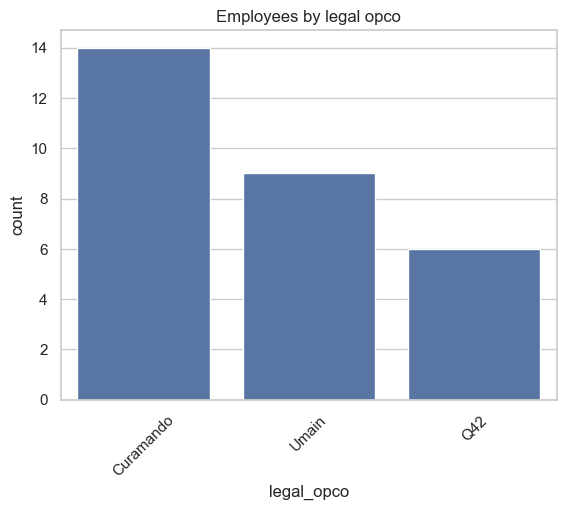

In [182]:
sns.countplot(data=df_employees, x="legal_opco")
plt.xticks(rotation=45)
plt.title("Employees by legal opco")
plt.show()

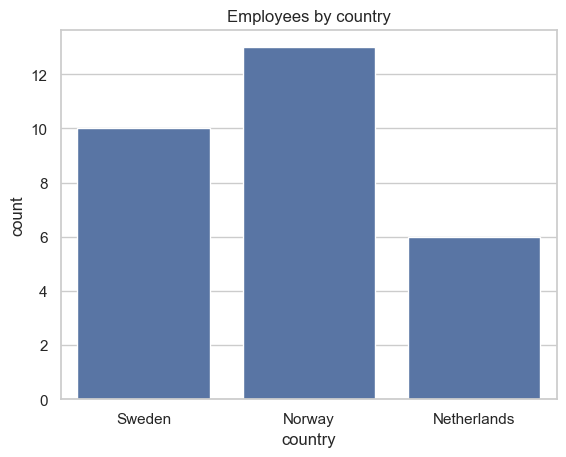

In [183]:
sns.countplot(data=df_employees, x="country")
plt.title("Employees by country")
plt.show()

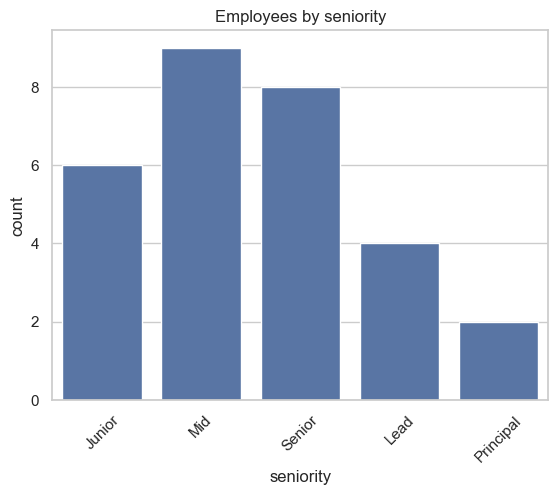

In [184]:
sns.countplot(data=df_employees, x="seniority",
              order=["Junior", "Mid", "Senior", "Lead", "Principal"])
plt.title("Employees by seniority")
plt.xticks(rotation=45)
plt.show()

c:\Users\makpe\OneDrive\Documents\Data Scientist\Curamando_trainee\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2714: UserWarning: A progress bar was requested, but there was an error loading the tqdm library. Please install tqdm to use the progress bar functionality.
  record_batch = self.to_arrow(


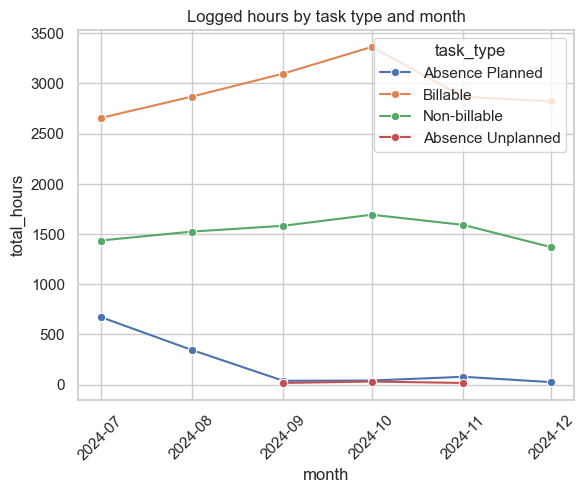

In [185]:
df_hours_by_month = read_gbq(f"""
SELECT
  DATE_TRUNC(date, MONTH) AS month,
  task_type,
  SUM(hours) AS total_hours
FROM `{PROJECT_ID}.{DATASET}.time_entries`
GROUP BY 1, 2
ORDER BY 1, 2
""", project_id=PROJECT_ID)

df_hours_by_month["month"] = pd.to_datetime(df_hours_by_month["month"])

sns.lineplot(data=df_hours_by_month, x="month", y="total_hours", hue="task_type", marker="o")
plt.title("Logged hours by task type and month")
plt.xticks(rotation=45)
plt.show()

c:\Users\makpe\OneDrive\Documents\Data Scientist\Curamando_trainee\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2714: UserWarning: A progress bar was requested, but there was an error loading the tqdm library. Please install tqdm to use the progress bar functionality.
  record_batch = self.to_arrow(


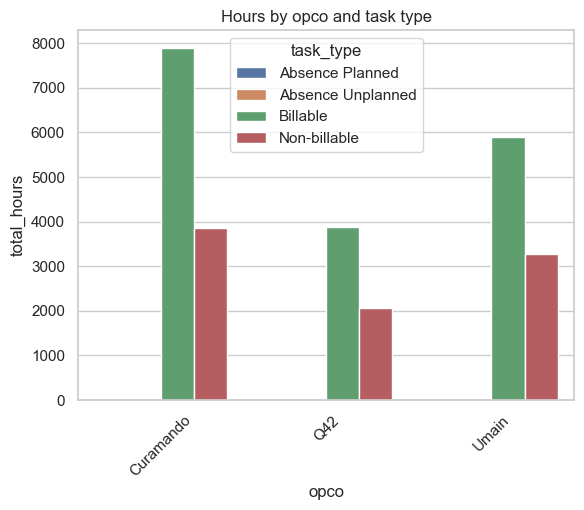

In [186]:
df_opco_hours = read_gbq(f"""
SELECT
  p.opco,
  t.task_type,
  SUM(t.hours) AS total_hours
FROM `{PROJECT_ID}.{DATASET}.time_entries` t
LEFT JOIN `{PROJECT_ID}.{DATASET}.projects` p
  ON t.project_id = p.project_id
GROUP BY 1, 2
ORDER BY 1, 2
""", project_id=PROJECT_ID)

sns.barplot(data=df_opco_hours, x="opco", y="total_hours", hue="task_type")
plt.title("Hours by opco and task type")
plt.xticks(rotation=45)
plt.show()

c:\Users\makpe\OneDrive\Documents\Data Scientist\Curamando_trainee\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2714: UserWarning: A progress bar was requested, but there was an error loading the tqdm library. Please install tqdm to use the progress bar functionality.
  record_batch = self.to_arrow(


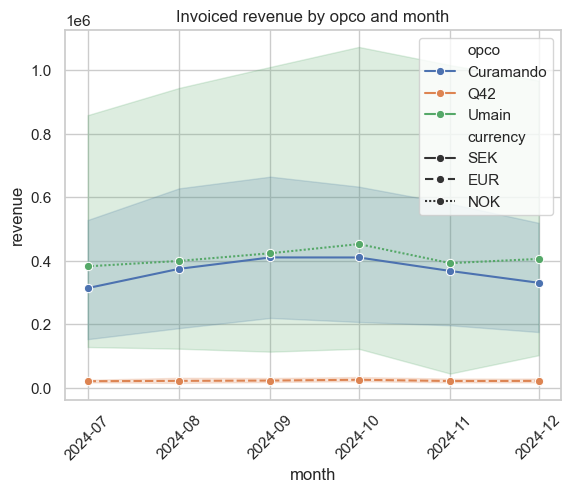

In [187]:
df_revenue = read_gbq(f"""
SELECT
  month,
  opco,
  revenue,
  currency
FROM `{PROJECT_ID}.{DATASET}.invoiced_revenue`
ORDER BY month, opco
""", project_id=PROJECT_ID)

df_revenue["month"] = pd.to_datetime(df_revenue["month"])

sns.lineplot(data=df_revenue, x="month", y="revenue", hue="opco", style="currency", marker="o")
plt.title("Invoiced revenue by opco and month")
plt.xticks(rotation=45)
plt.show()

In [202]:
chargeability_query = """
WITH employee_base AS (
  SELECT
    employee_id,
    name,
    COALESCE(works_for_opco, legal_opco) AS reporting_opco,
    country,
    employment_type,
    seniority,
    date_of_hiring,
    last_working_day
  FROM `eidra-df-case.eidra_data_trainee.employees`
),

employee_calendar AS (
  SELECT
    e.employee_id,
    e.name,
    e.reporting_opco,
    e.country,
    e.employment_type,
    e.seniority,
    c.date,
    DATE_TRUNC(c.date, MONTH) AS month,
    c.working_hours
  FROM employee_base e
  JOIN `eidra-df-case.eidra_data_trainee.calendar` c
    ON e.country = c.country
  WHERE c.is_working_day = TRUE
    AND c.date >= GREATEST(e.date_of_hiring, DATE_TRUNC(c.date, MONTH))
    AND c.date <= LEAST(COALESCE(e.last_working_day, DATE '2024-12-31'), LAST_DAY(c.date))
),

monthly_available_hours AS (
  SELECT
    employee_id,
    name,
    reporting_opco,
    country,
    employment_type,
    seniority,
    month,
    SUM(working_hours) AS available_hours
  FROM employee_calendar
  GROUP BY 1,2,3,4,5,6,7
),

monthly_billable_hours AS (
  SELECT
    employee_id,
    DATE_TRUNC(date, MONTH) AS month,
    SUM(hours) AS billable_hours
  FROM `eidra-df-case.eidra_data_trainee.time_entries`
  WHERE task_type = 'Billable'
  GROUP BY 1,2
),

monthly_absence_hours AS (
  SELECT
    employee_id,
    DATE_TRUNC(date, MONTH) AS month,
    SUM(hours) AS absence_hours
  FROM `eidra-df-case.eidra_data_trainee.time_entries`
  WHERE task_type IN ('Absence Planned', 'Absence Unplanned')
  GROUP BY 1,2
),

final AS (
  SELECT
    a.employee_id,
    a.name,
    a.reporting_opco AS opco,
    a.country,
    a.employment_type,
    a.seniority,
    a.month,
    a.available_hours,
    COALESCE(abs.absence_hours, 0) AS absence_hours,
    COALESCE(b.billable_hours, 0) AS billable_hours,

    -- Adjusted denominator
    (a.available_hours - COALESCE(abs.absence_hours, 0)) AS net_available_hours,

    SAFE_DIVIDE(
      COALESCE(b.billable_hours, 0),
      (a.available_hours - COALESCE(abs.absence_hours, 0))
    ) AS chargeability_pct

  FROM monthly_available_hours a
  LEFT JOIN monthly_billable_hours b
    ON a.employee_id = b.employee_id
   AND a.month = b.month
  LEFT JOIN monthly_absence_hours abs
    ON a.employee_id = abs.employee_id
   AND a.month = abs.month
)

SELECT *
FROM final
ORDER BY month, opco, name;
"""

df_charge = read_gbq(chargeability_query, project_id="eidra-df-case")
df_charge.head()

c:\Users\makpe\OneDrive\Documents\Data Scientist\Curamando_trainee\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2714: UserWarning: A progress bar was requested, but there was an error loading the tqdm library. Please install tqdm to use the progress bar functionality.
  record_batch = self.to_arrow(


,employee_id,name,opco,country,employment_type,seniority,month,available_hours,absence_hours,billable_hours,net_available_hours,chargeability_pct
0,EMP-001,Anna Lindberg,Curamando,Sweden,Full-time,Senior,2024-07-01,184.0,80.0,87.9,104.0,0.845192
1,EMP-007,Ella Pettersson,Curamando,Sweden,Full-time,Principal,2024-07-01,184.0,0.0,25.3,184.0,0.137500
2,EMP-002,Erik Johansson,Curamando,Sweden,Full-time,Mid,2024-07-01,184.0,64.0,110.3,120.0,0.919167
3,EMP-008,Hugo Larsson,Curamando,Sweden,Full-time,Junior,2024-07-01,184.0,0.0,151.5,184.0,0.823370
4,EMP-026,Kristian Vik,Curamando,Norway,Full-time,Senior,2024-07-01,172.5,75.0,69.5,97.5,0.712821


In [203]:
df_charge["chargeability_pct"] = df_charge["chargeability_pct"].astype(float)

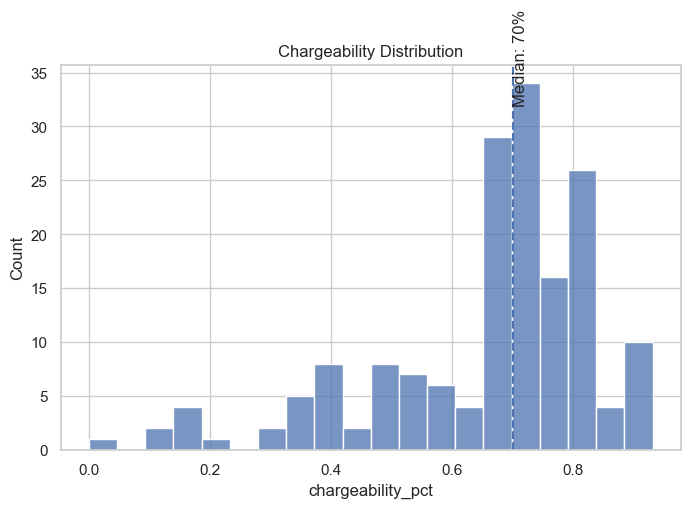

In [204]:
plt.figure(figsize=(8,5))

sns.histplot(df_charge["chargeability_pct"], bins=20)

# Median
median_val = df_charge["chargeability_pct"].median()

plt.axvline(median_val, linestyle="--")
plt.text(median_val, plt.ylim()[1]*0.9, f"Median: {median_val:.0%}", rotation=90)

plt.title("Chargeability Distribution")
plt.show()

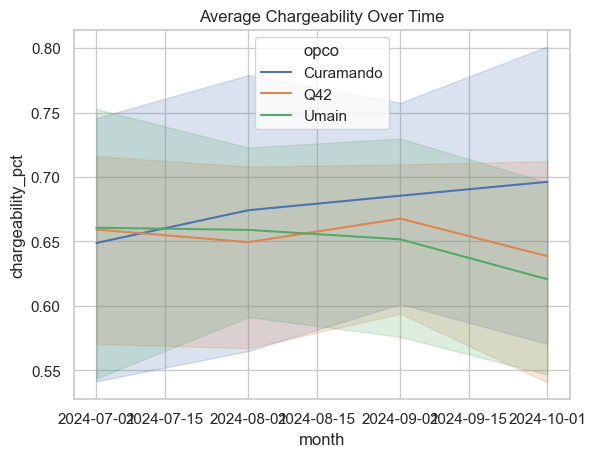

In [207]:
df_charge["month"] = pd.to_datetime(df_charge["month"])

sns.lineplot(data=df_charge, x="month", y="chargeability_pct", hue="opco", estimator="mean")
plt.title("Average Chargeability Over Time")
plt.show()

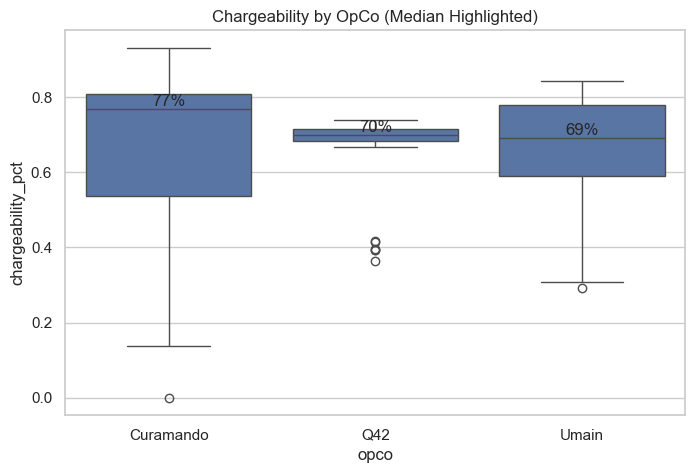

In [209]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(data=df_charge, x="opco", y="chargeability_pct")

# Add median labels per opco
medians = df_charge.groupby("opco")["chargeability_pct"].median()

for i, opco in enumerate(medians.index):
    ax.text(
        i,
        medians[opco],
        f'{medians[opco]:.0%}',
        ha='center',
        va='bottom'
    )

plt.title("Chargeability by OpCo (Median Highlighted)")
plt.show()

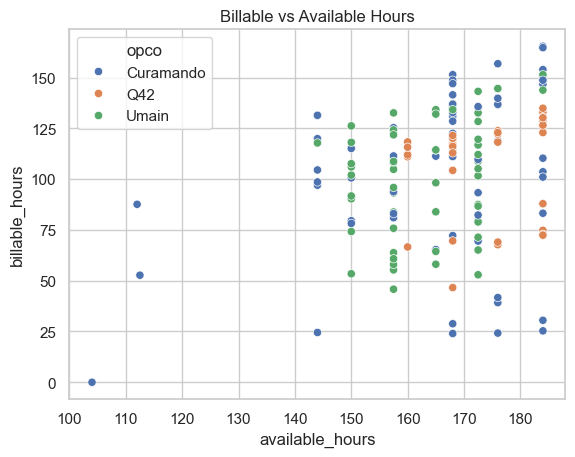

In [210]:
sns.scatterplot(
    data=df_charge,
    x="available_hours",
    y="billable_hours",
    hue="opco"
)
plt.title("Billable vs Available Hours")
plt.show()

In [211]:
revenue_query = """
WITH billable_time AS (
  SELECT
    t.employee_id,
    DATE_TRUNC(t.date, MONTH) AS month,
    p.client_id,
    p.opco,
    SUM(t.hours) AS billable_hours
  FROM `eidra-df-case.eidra_data_trainee.time_entries` t
  JOIN `eidra-df-case.eidra_data_trainee.projects` p
    ON t.project_id = p.project_id
  WHERE t.task_type = 'Billable'
    AND p.client_id IS NOT NULL
  GROUP BY 1,2,3,4
),

employee_rates AS (
  SELECT
    e.employee_id,
    e.seniority,
    COALESCE(e.works_for_opco, e.legal_opco) AS reporting_opco,
    r.standard_rate,
    r.currency
  FROM `eidra-df-case.eidra_data_trainee.employees` e
  JOIN `eidra-df-case.eidra_data_trainee.billing_rates` r
    ON COALESCE(e.works_for_opco, e.legal_opco) = r.opco
   AND e.seniority = r.seniority
),

theoretical_revenue AS (
  SELECT
    b.employee_id,
    b.month,
    b.client_id,
    b.opco,
    b.billable_hours,
    er.standard_rate,
    er.currency,
    b.billable_hours * er.standard_rate AS theoretical_revenue
  FROM billable_time b
  JOIN employee_rates er
    ON b.employee_id = er.employee_id
),

client_month_totals AS (
  SELECT
    t.client_id,
    t.opco,
    t.month,
    SUM(t.theoretical_revenue) AS total_theoretical_revenue
  FROM theoretical_revenue t
  GROUP BY 1,2,3
),

revenue_share AS (
  SELECT
    t.employee_id,
    t.client_id,
    t.opco,
    t.month,
    t.theoretical_revenue,
    SAFE_DIVIDE(
      t.theoretical_revenue,
      c.total_theoretical_revenue
    ) AS revenue_share
  FROM theoretical_revenue t
  JOIN client_month_totals c
    ON t.client_id = c.client_id
   AND t.opco = c.opco
   AND t.month = c.month
),

final AS (
  SELECT
    rs.employee_id,
    rs.client_id,
    rs.opco,
    rs.month,
    rs.revenue_share,
    ir.revenue AS actual_revenue,
    rs.revenue_share * ir.revenue AS attributed_revenue,
    ir.currency
  FROM revenue_share rs
  JOIN `eidra-df-case.eidra_data_trainee.invoiced_revenue` ir
    ON rs.client_id = ir.client_id
   AND rs.opco = ir.opco
   AND rs.month = ir.month
)

SELECT
  *,
  
  -- Rank within client
  ROW_NUMBER() OVER (
    PARTITION BY client_id, opco, month
    ORDER BY revenue_share DESC
  ) AS rank_in_client,

  -- Cumulative share (concentration)
  SUM(revenue_share) OVER (
    PARTITION BY client_id, opco, month
    ORDER BY revenue_share DESC
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
  ) AS cumulative_share

FROM final
ORDER BY month, opco, client_id, rank_in_client;
"""

df_revenue = read_gbq(revenue_query, project_id="eidra-df-case")

df_revenue["month"] = pd.to_datetime(df["month"])

c:\Users\makpe\OneDrive\Documents\Data Scientist\Curamando_trainee\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2714: UserWarning: A progress bar was requested, but there was an error loading the tqdm library. Please install tqdm to use the progress bar functionality.
  record_batch = self.to_arrow(


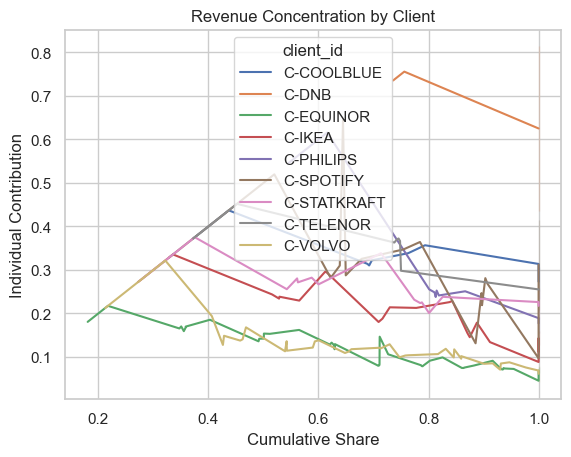

In [212]:
df_sorted = df_revenue.sort_values(
    ["client_id", "opco", "month", "revenue_share"],
    ascending=[True, True, True, False]
)

df_sorted["cumulative_share"] = df_sorted.groupby(
    ["client_id", "opco", "month"]
)["revenue_share"].cumsum()

sns.lineplot(
    data=df_sorted,
    x="cumulative_share",
    y="revenue_share",
    hue="client_id"
)
plt.title("Revenue Concentration by Client")
plt.xlabel("Cumulative Share")
plt.ylabel("Individual Contribution")
plt.show()

In [213]:
top1 = df_sorted.groupby(
    ["client_id", "opco", "month"]
).head(1)

# Optional: filter one month for clarity (recommended for slides)
top1 = top1[top1["month"] == top1["month"].min()]

# Sort for clean visual
top1 = top1.sort_values("revenue_share", ascending=True)

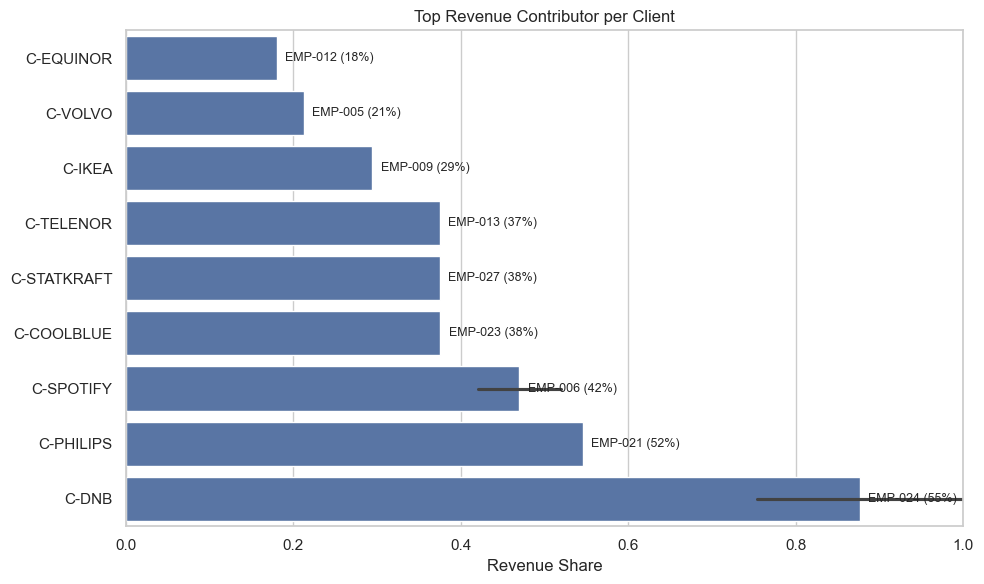

In [214]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top1,
    y="client_id",
    x="revenue_share"
)

# Add labels directly on bars
for bar, (_, row) in zip(ax.patches, top1.iterrows()):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{row["employee_id"]} ({row["revenue_share"]:.0%})',
        va='center',
        fontsize=9
    )

plt.title("Top Revenue Contributor per Client")
plt.xlabel("Revenue Share")
plt.ylabel("")

plt.xlim(0, 1)  # since it's a percentage

plt.tight_layout()
plt.show()

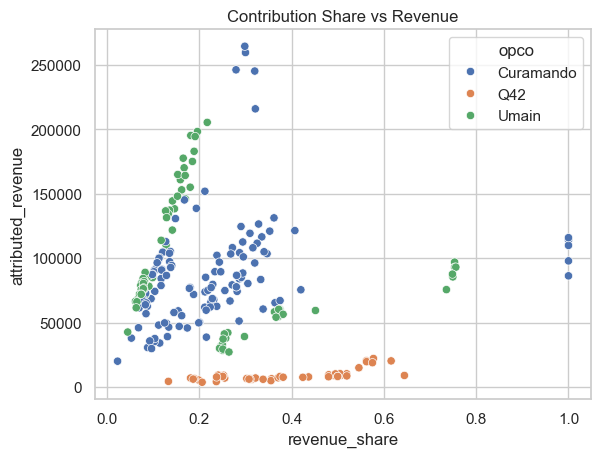

In [215]:
sns.scatterplot(
    data=df_revenue,
    x="revenue_share",
    y="attributed_revenue",
    hue="opco"
)
plt.title("Contribution Share vs Revenue")
plt.show()

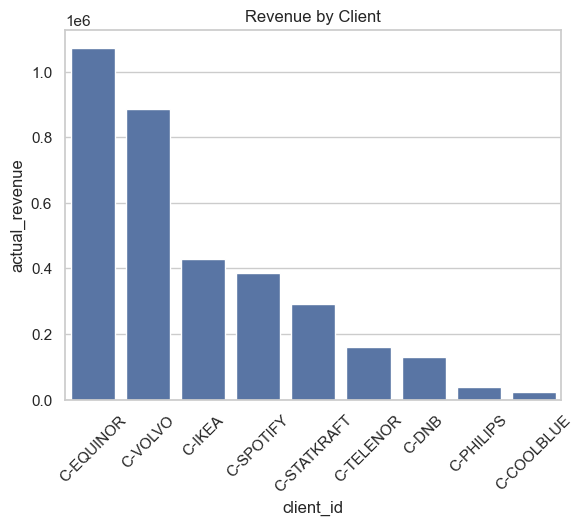

In [216]:
df_client = df_revenue.groupby("client_id")["actual_revenue"].max().reset_index()

sns.barplot(
    data=df_client.sort_values("actual_revenue", ascending=False),
    x="client_id",
    y="actual_revenue"
)
plt.title("Revenue by Client")
plt.xticks(rotation=45)
plt.show()

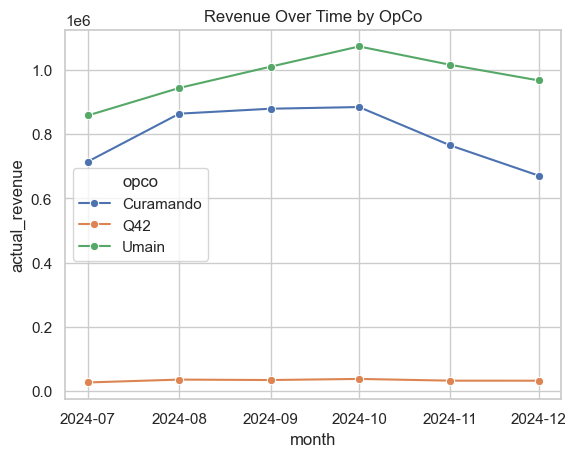

In [217]:
df_time = df_revenue.groupby(["month", "opco"])["actual_revenue"].max().reset_index()

sns.lineplot(
    data=df_time,
    x="month",
    y="actual_revenue",
    hue="opco",
    marker="o"
)
plt.title("Revenue Over Time by OpCo")
plt.show()

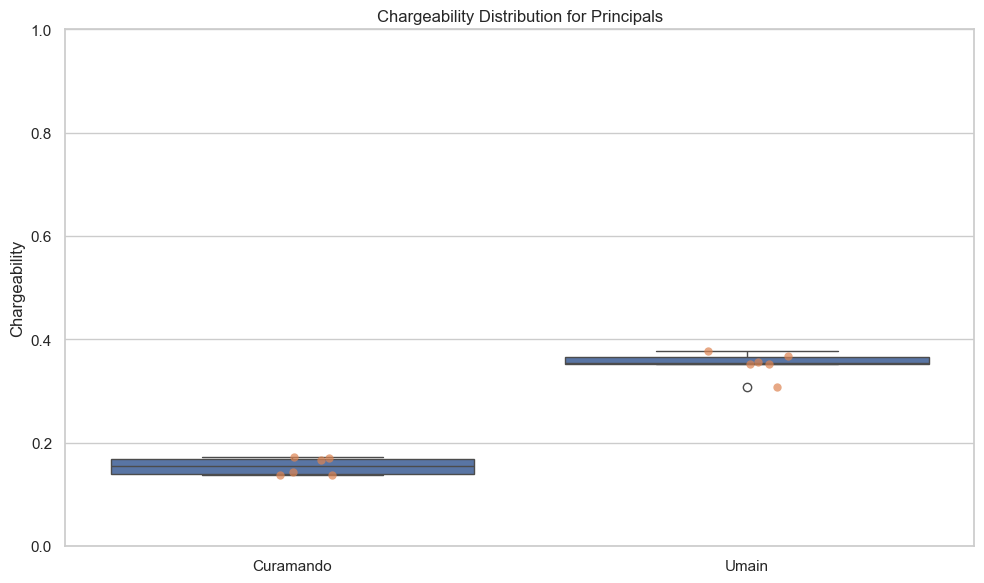

In [219]:
principals = df_charge[df_charge["seniority"] == "Principal"]

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=principals,
    x="opco",
    y="chargeability_pct"
)

sns.stripplot(
    data=principals,
    x="opco",
    y="chargeability_pct",
    size=6,
    alpha=0.7
)

plt.title("Chargeability Distribution for Principals")
plt.ylabel("Chargeability")
plt.xlabel("")

plt.ylim(0,1)

plt.tight_layout()
plt.show()

<Axes: xlabel='seniority', ylabel='chargeability_pct'>

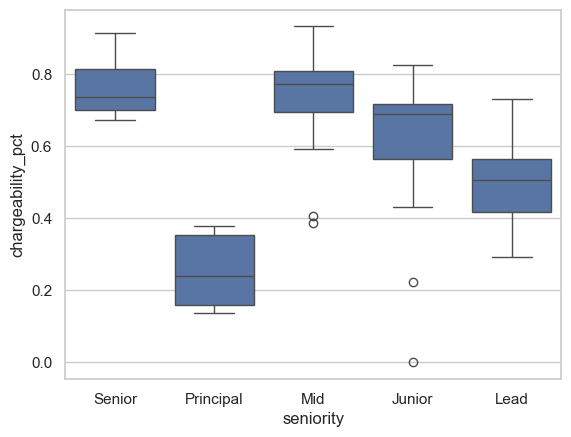

In [220]:
sns.boxplot(data=df_charge, x="seniority", y="chargeability_pct")

In [236]:
revdiff_query = """WITH base AS (
  SELECT
    t.employee_id,
    DATE_TRUNC(t.date, MONTH) AS month,
    p.client_id,
    p.opco,
    t.hours,
    br.standard_rate,
    (t.hours * br.standard_rate) AS theoretical_revenue
  FROM `eidra-df-case.eidra_data_trainee.time_entries` t
  JOIN `eidra-df-case.eidra_data_trainee.projects` p
    ON t.project_id = p.project_id
  JOIN `eidra-df-case.eidra_data_trainee.employees` e
    ON t.employee_id = e.employee_id
  JOIN `eidra-df-case.eidra_data_trainee.billing_rates` br
    ON br.opco = COALESCE(e.works_for_opco, e.legal_opco)
   AND br.seniority = e.seniority
  WHERE t.task_type = 'Billable'
    AND p.client_id IS NOT NULL
),

client_month AS (
  SELECT
    client_id,
    opco,
    month,
    SUM(theoretical_revenue) AS total_theoretical_revenue
  FROM base
  GROUP BY 1,2,3
),

actuals AS (
  SELECT
    client_id,
    opco,
    month,
    revenue AS actual_revenue
  FROM `eidra-df-case.eidra_data_trainee.invoiced_revenue`
)

SELECT
  c.client_id,
  c.opco,
  c.month,
  c.total_theoretical_revenue,
  a.actual_revenue,
  (a.actual_revenue - c.total_theoretical_revenue) AS revenue_gap,
  SAFE_DIVIDE(a.actual_revenue, c.total_theoretical_revenue) AS revenue_ratio
FROM client_month c
LEFT JOIN actuals a
  ON c.client_id = a.client_id
 AND c.opco = a.opco
 AND c.month = a.month"""

df_revdiff = read_gbq(revdiff_query, project_id="eidra-df-case")

df_revdiff["month"] = pd.to_datetime(df_revdiff["month"])

c:\Users\makpe\OneDrive\Documents\Data Scientist\Curamando_trainee\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2714: UserWarning: A progress bar was requested, but there was an error loading the tqdm library. Please install tqdm to use the progress bar functionality.
  record_batch = self.to_arrow(


In [237]:
df.columns

Index(['employee_id', 'client_id', 'opco', 'month', 'revenue_share',
       'actual_revenue', 'attributed_revenue', 'currency', 'rank_in_client',
       'cumulative_share'],
      dtype='object')

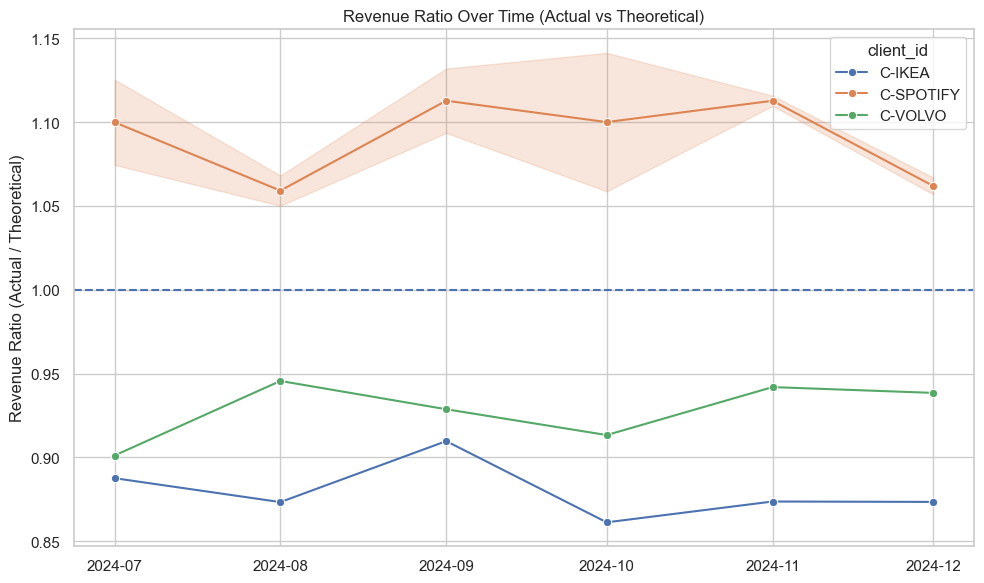

In [238]:
# Filter key clients (keeps chart clean)
key_clients = ["C-IKEA", "C-SPOTIFY", "C-VOLVO"]

df_plot = df_revdiff[df_revdiff["client_id"].isin(key_clients)].copy()
df_plot["month"] = pd.to_datetime(df_plot["month"])

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_plot,
    x="month",
    y="revenue_ratio",
    hue="client_id",
    marker="o"
)

# Reference line at 1 (perfect billing)
plt.axhline(1, linestyle="--")

plt.title("Revenue Ratio Over Time (Actual vs Theoretical)")
plt.ylabel("Revenue Ratio (Actual / Theoretical)")
plt.xlabel("")

plt.tight_layout()
plt.show()

In [243]:
# Total revenue
total_revenue = df_revdiff["actual_revenue"].sum()

# Revenue from Equinor + Volvo
key_clients = ["C-EQUINOR", "C-VOLVO"]

key_revenue = df_revdiff[df_revdiff["client_id"].isin(key_clients)]["actual_revenue"].sum()

# Ratio
ratio = key_revenue / total_revenue

print(f"Equinor + Volvo share: {ratio:.2%}")

Equinor + Volvo share: 56.66%


In [244]:
other_revenue = total_revenue - key_revenue

print(f"Key clients: {key_revenue:,.0f}")
print(f"Others: {other_revenue:,.0f}")
print(f"Ratio (Key / Others): {key_revenue / other_revenue:.2f}")

Key clients: 10,649,452
Others: 8,147,337
Ratio (Key / Others): 1.31


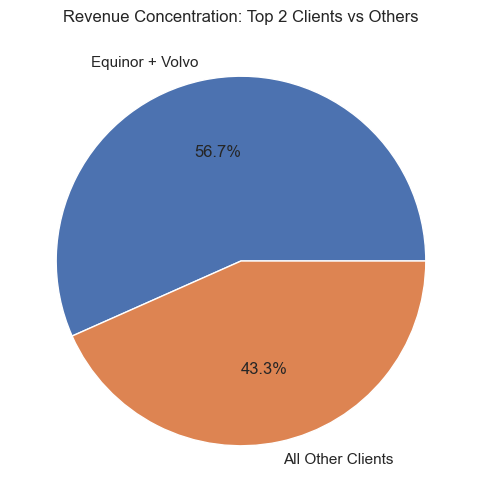

In [245]:
labels = ["Equinor + Volvo", "All Other Clients"]
values = [key_revenue, other_revenue]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Revenue Concentration: Top 2 Clients vs Others")
plt.show()

In [ ]:
# Aggregate revenue per opco
df_opco = df_revenue.groupby("opco")["actual_revenue"].sum().reset_index()

# Total revenue
total_revenue = df_opco["actual_revenue"].sum()

# Share
df_opco["revenue_share"] = df_opco["actual_revenue"] / total_revenue
df_opco["revenue_share_pct"] = (df_opco["revenue_share"] * 100).round(0).astype(int).astype(str) + "%"

df_opco = df_opco.drop(columns=["revenue_share"])

df_opco

,opco,actual_revenue,revenue_share_pct
0,Curamando,61140078.10,52%
1,Q42,1170072.26,1%
2,Umain,54691316.36,47%


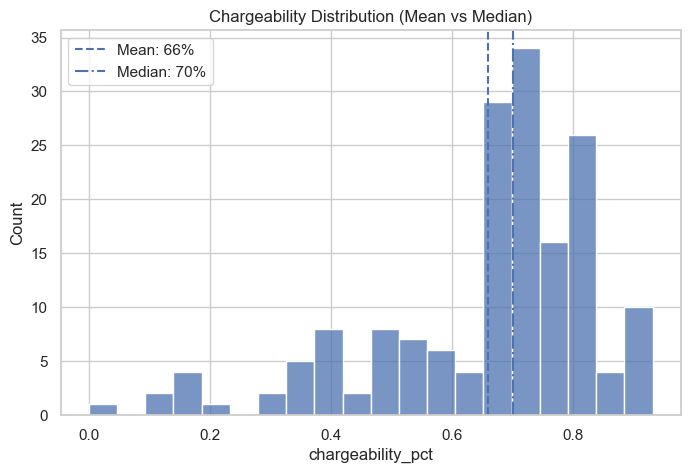

In [231]:
plt.figure(figsize=(8,5))

sns.histplot(df_charge["chargeability_pct"], bins=20)

mean_val = df_charge["chargeability_pct"].mean()
median_val = df_charge["chargeability_pct"].median()

plt.axvline(mean_val, linestyle="--", label=f"Mean: {mean_val:.0%}")
plt.axvline(median_val, linestyle="-.", label=f"Median: {median_val:.0%}")

plt.legend()
plt.title("Chargeability Distribution (Mean vs Median)")
plt.show()